# Dự án Churn Prediction - Giai đoạn 1: EDA & Làm sạch dữ liệu
**Người thực hiện:** AIE Data
**Mục tiêu:** Phân tích các yếu tố dẫn đến rời bỏ dịch vụ và chuẩn bị dữ liệu sạch cho Model.

# Tách dữ liệu raw thành 2 bộ dữ liệu train và test

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import os

# 1. Đường dẫn (Sử dụng r"" để tránh lỗi gạch chéo)
path = r"D:\AIO Tài liệu\Warm up 04\Project 01\Churn-Prediction\data\raw\ecommerce_churn.xlsx"

# 2. Đọc Sheet thứ 2 (sheet_name=1)
# Nếu máy báo lỗi "ImportError: Missing optional dependency 'openpyxl'", 
# bạn hãy vào Terminal gõ: pip install openpyxl
df = pd.read_excel(path, sheet_name="E Comm")

# 3. Làm sạch tên cột (đề phòng khoảng trắng thừa)
df.columns = df.columns.str.strip()

# Kiểm tra thử xem đã thấy cột Churn chưa
print("Danh sách cột đã tìm thấy:", df.columns.tolist())
print(f"Tổng số dòng dữ liệu: {len(df)}")

# 4. Nếu đã thấy cột 'Churn', tiến hành chia dữ liệu
if 'Churn' in df.columns:
    train_df, test_df = train_test_split(
        df, 
        test_size=0.2, 
        random_state=42, 
        stratify=df['Churn']
    )
    
    # 5. Lưu vào thư mục processed
    os.makedirs('../data/processed', exist_ok=True)
    train_df.to_csv('../data/processed/train.csv', index=False)
    test_df.to_csv('../data/processed/test.csv', index=False)
    print("--- THÀNH CÔNG: Đã chia Train/Test và lưu file! ---")
else:
    print("Vẫn chưa tìm thấy cột 'Churn'. Hãy kiểm tra lại tên Sheet!")

: 

# Kiểm tra missing value

In [10]:
import pandas as pd
# Đọc lại tập train đã lưu
train_df = pd.read_csv('../data/processed/train.csv')

# Kiểm tra các cột có giá trị thiếu
missing_data = train_df.isnull().sum()
print("Các cột bị thiếu dữ liệu:\n", missing_data[missing_data > 0])

Các cột bị thiếu dữ liệu:
 Tenure                         213
WarehouseToHome                206
HourSpendOnApp                 197
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
dtype: int64


**Nhận xét**
Tenure (Thâm niên): Thiếu 213. Đây là biến cực kỳ quan trọng. Khách hàng mới thường dễ bỏ đi hơn khách hàng cũ.
DaySinceLastOrder (Ngày từ đơn hàng cuối): Thiếu 247 (nhiều nhất). Biến này đo lường độ "nóng" của khách hàng.
WarehouseToHome (Kho đến nhà): Thiếu 206. Khoảng cách địa lý ảnh hưởng đến tốc độ giao hàng.
=> Vá lỗ hổng bằng trung vị

In [11]:
# 1. Danh sách các cột cần vá (Numerical columns)
cols_to_fix = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 
    'OrderCount', 'DaySinceLastOrder'
]

# 2. Vá lỗi bằng Median (Trung vị)
for col in cols_to_fix:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)

# 3. Kiểm tra lại xem còn lỗ hổng nào không
print("Số lượng giá trị thiếu sau khi vá:")
print(train_df.isnull().sum().sum())

Số lượng giá trị thiếu sau khi vá:
0


# Kiểm tra tỷ lệ rời bỏ Churn

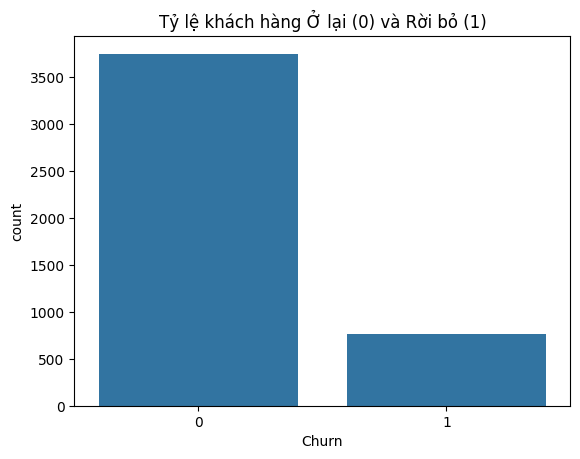

Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ biểu đồ đếm số lượng
sns.countplot(x='Churn', data=train_df)
plt.title('Tỷ lệ khách hàng Ở lại (0) và Rời bỏ (1)')
plt.show()

# Xem tỷ lệ phần trăm cụ thể
print(train_df['Churn'].value_counts(normalize=True) * 100)

# Kiểm tra trùng lặp và điểm dị biệt (outliers)

In [4]:
# Kiểm tra số lượng dòng trùng lặp
duplicate_count = train_df.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")

# Nếu có, chúng ta sẽ xóa bỏ và chỉ giữ lại dòng đầu tiên
if duplicate_count > 0:
    train_df = train_df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp!")

Số lượng dòng trùng lặp: 0


In [7]:
# 1. Tìm tất cả các cột số
num_features = train_df.select_dtypes(include=['int64', 'float64']).columns

# 2. Tính toán tỷ lệ Outlier ở mỗi cột
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((df[col] < lower) | (df[col] > upper)).sum()

for col in num_features:
    outlier_count = count_outliers(train_df, col)
    if outlier_count > 0:
        percentage = (outlier_count / len(train_df)) * 100
        print(f"Cột {col}: có {outlier_count} outliers ({percentage:.2f}%)")

Cột Churn: có 758 outliers (16.83%)
Cột Tenure: có 2 outliers (0.04%)
Cột WarehouseToHome: có 1 outliers (0.02%)
Cột HourSpendOnApp: có 4 outliers (0.09%)
Cột NumberOfDeviceRegistered: có 327 outliers (7.26%)
Cột NumberOfAddress: có 3 outliers (0.07%)
Cột OrderAmountHikeFromlastYear: có 28 outliers (0.62%)
Cột CouponUsed: có 502 outliers (11.15%)
Cột OrderCount: có 545 outliers (12.10%)
Cột DaySinceLastOrder: có 42 outliers (0.93%)
Cột CashbackAmount: có 343 outliers (7.62%)


# Vẽ đồ thị outliers các cột#

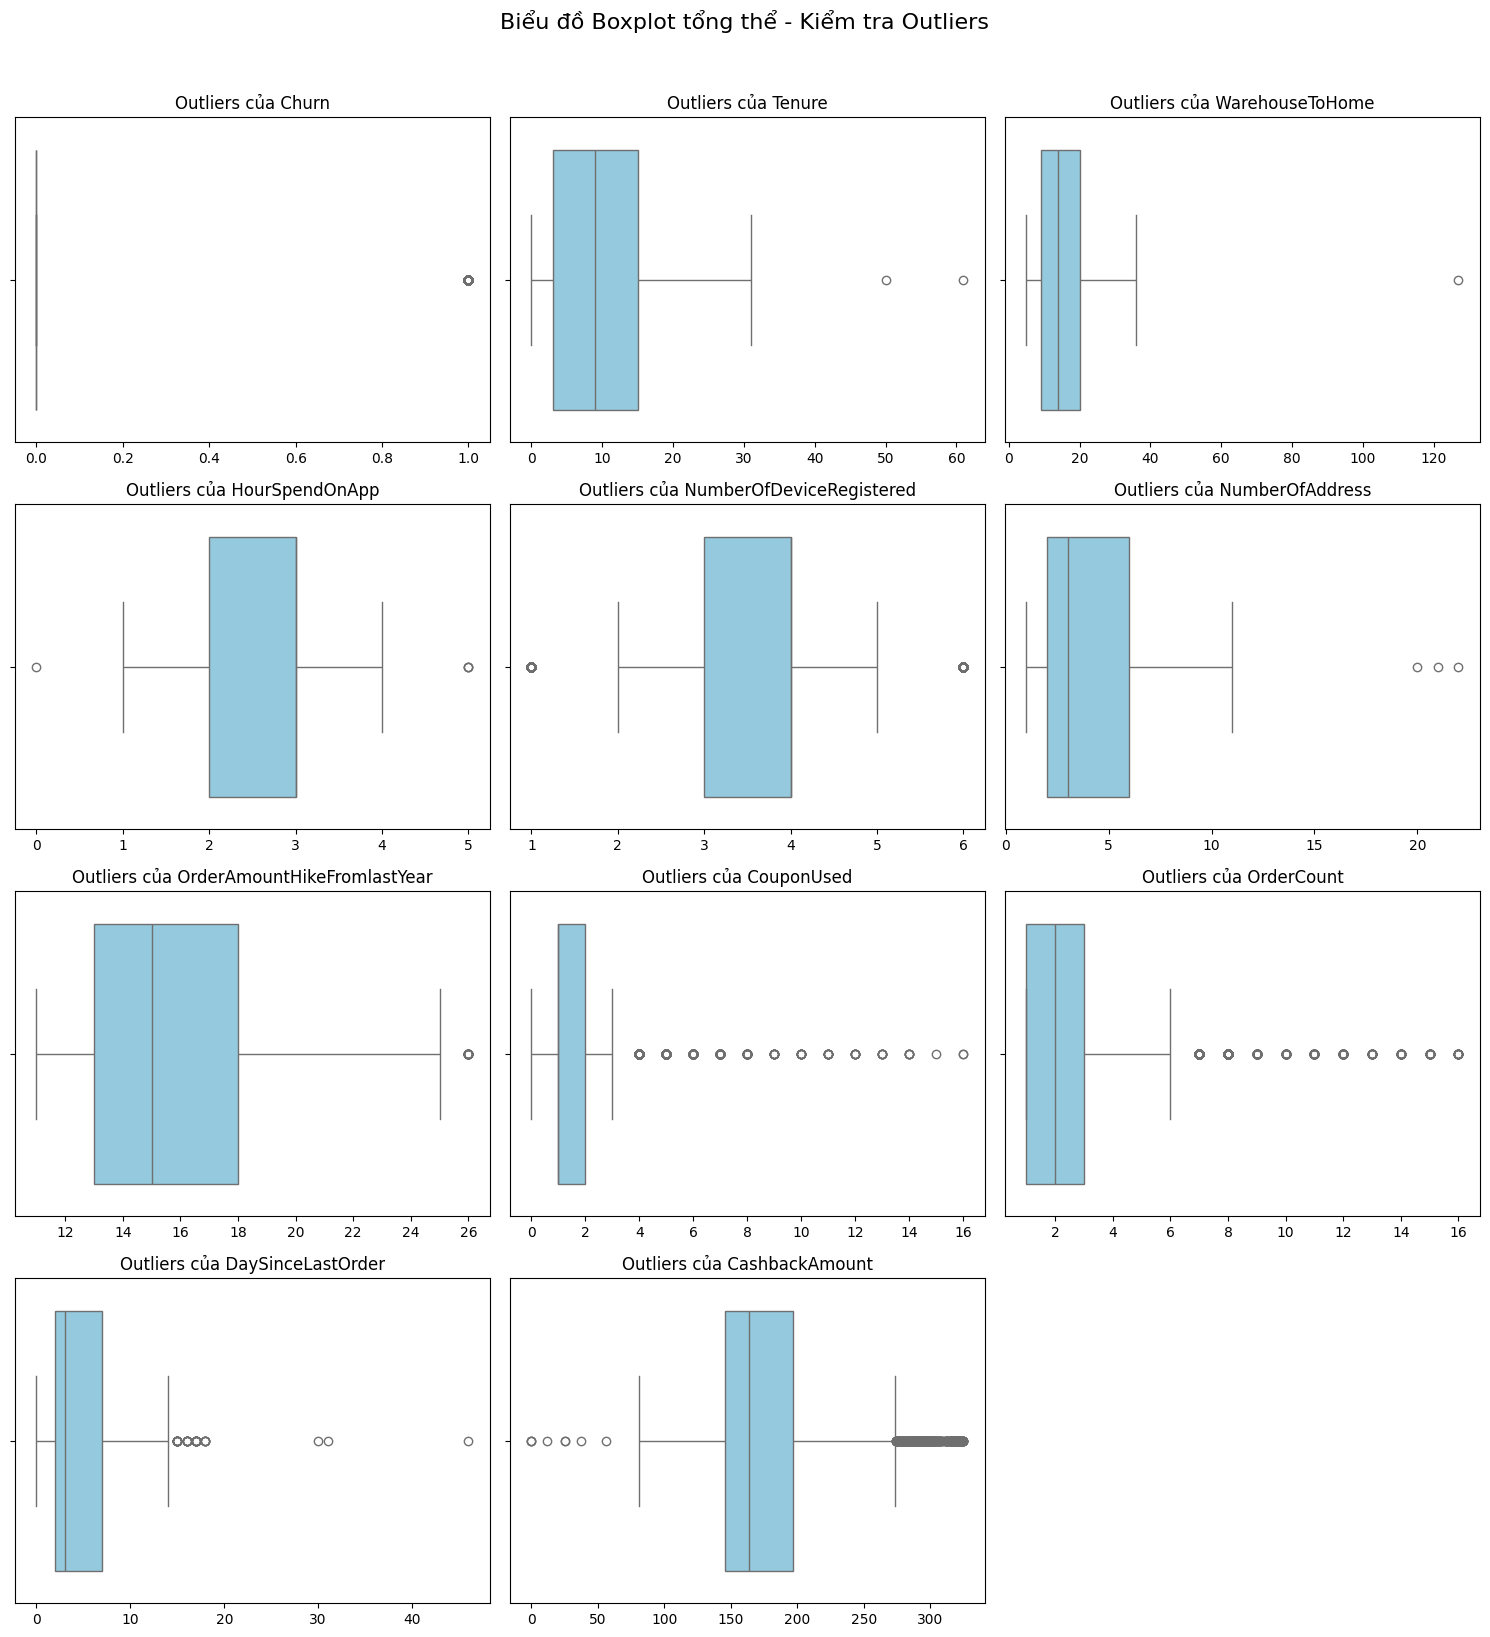

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Danh sách các cột bạn muốn vẽ (dựa trên danh sách bạn đã liệt kê)
num_features = [
    'Churn', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 
    'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

# 2. Tính toán số hàng và số cột cho khung hình (Grid)
# Ví dụ: 11 cột thì chia thành 4 hàng, mỗi hàng 3 biểu đồ
n_cols = 3
n_rows = math.ceil(len(num_features) / n_cols)

# 3. Khởi tạo khung hình
plt.figure(figsize=(15, n_rows * 4))
plt.suptitle('Biểu đồ Boxplot tổng thể - Kiểm tra Outliers', fontsize=16, y=1.02)

for i, col in enumerate(num_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Outliers của {col}')
    plt.xlabel('') # Ẩn tên cột ở trục X cho đỡ rối

# 4. Tự động căn chỉnh để các biểu đồ không đè lên nhau
plt.tight_layout()
plt.show()

# Dùng phương pháp IQR để xử lý outlier và endcoding các dữ liệu chữ thành dữ liệu 0 và 1

In [9]:
import pandas as pd

# A. ĐỊNH NGHĨA LẠI HÀM (Để máy nhớ lại cách xử lý Outlier)
def handle_outliers(df, column):
    # Sử dụng phương pháp IQR (Interquartile Range) [cite: 576]
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Capping: Thay thế giá trị ngoài biên bằng giá trị biên [cite: 576]
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

# B. THỰC HIỆN XỬ LÝ CHIẾN THUẬT [cite: 642]
# Chỉ cắt những cột có Outlier cực thấp (<1%) để tránh mất tín hiệu quan trọng 
cols_to_cap = ['WarehouseToHome', 'Tenure', 'DaySinceLastOrder']

for col in cols_to_cap:
    train_df = handle_outliers(train_df, col)

# C. CHUẨN HÓA LẦN CUỐI (Encoding) [cite: 114, 503, 642]
cat_cols = train_df.select_dtypes(include=['object']).columns
train_final = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)

# D. LƯU FILE "VÀNG" [cite: 595, 642]
import os
os.makedirs('../data/processed', exist_ok=True)
train_final.to_csv('../data/processed/cleaned_data.csv', index=False)

print("--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---")
print(f"Số lượng cột cuối cùng: {train_final.shape[1]}")

--- CHÚC MỪNG: DỮ LIỆU ĐÃ SẠCH VÀ CHUẨN CHIẾN THUẬT! ---
Số lượng cột cuối cùng: 31


C:\Users\tpbin\AppData\Local\Temp\ipykernel_21004\1490404264.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object']).columns
